In [75]:
import os 
from pathlib import Path
import numpy as np
import glob
import xarray as xr
import cartopy.crs as ccrs
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import cartopy.feature as cfeature
os.chdir(Path('/home/globc/garcia/'))

from scenarIA.src.utils.datautils import weighted_global_mean
from scenarIA.src.utils.plotutils import plot_mean_std_simulations
from scenarIA.src.utils.settings import DATASET_DIR, GRAPHS_DIR

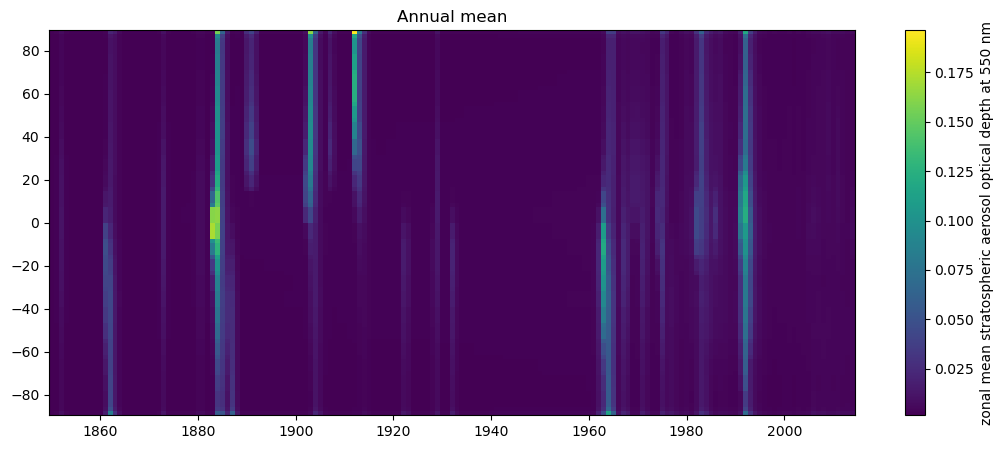

In [80]:
file = '/gpfs-calypso/scratch/globc/garcia/scenarIA/rawdata/input4mips/tau_reff_CMIP6.v3_regrid.nc'
ds = xr.open_dataset(file).sel(month=slice(None, '2014')).resample(month='YS').mean(dim='month').isel(lon=23)
plt.figure(figsize=(13,5))
x, y = np.meshgrid(ds.month.values, ds.lat.values)
plt.pcolormesh(x, y, ds.tau.values.transpose(), shading='nearest')
plt.title('Annual mean')
cbar = plt.colorbar()
cbar.set_label(ds.tau.attrs['long_name'])
plt.show()

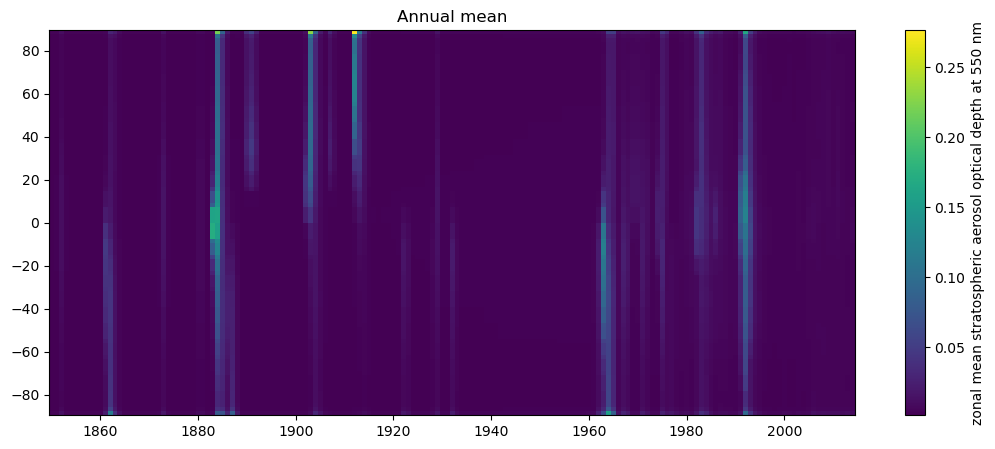

In [78]:
file = '/gpfs-calypso/scratch/globc/garcia/scenarIA/rawdata/input4mips/tau_reff_CMIP6.v3_regrid.nc'
ds = xr.open_dataset(file).sel(month=slice(None, '2014')).resample(month='YS').mean(dim='month').isel(lon=50)
plt.figure(figsize=(13,5))
x, y = np.meshgrid(ds.month.values, ds.lat.values)
plt.pcolormesh(x, y, ds.tau.values.transpose(), shading='nearest')
plt.title('Annual mean')
cbar = plt.colorbar()
cbar.set_label(ds.tau.attrs['long_name'])
plt.show()

(165,) (165,)


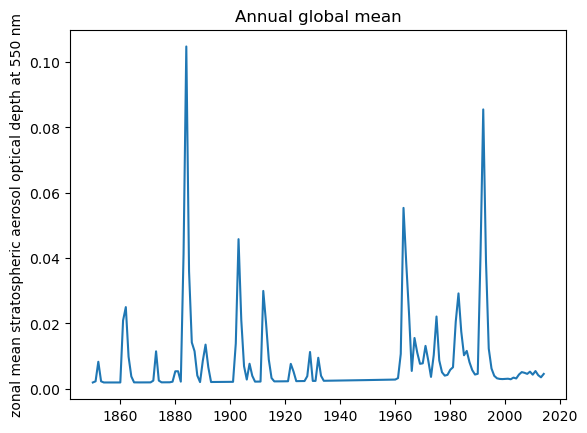

In [68]:
tau_mean = weighted_global_mean(ds.tau).values
print(ds.month.values.shape, tau_mean.shape)
plt.figure()
plt.plot(ds.month.values, tau_mean)
plt.ylabel(ds.tau.attrs['long_name'])
plt.title('Annual global mean')
plt.show()

In [72]:
file = '/gpfs-calypso/scratch/globc/garcia/scenarIA/rawdata/input4mips/multiple-transitions_input4MIPs_landState_ScenarioMIP_UofMD-IMAGE-ssp126-2-1-f_gn_2015-2100.nc'
ds = xr.open_dataset(file, decode_times=False)
ds

<xarray.Dataset> Size: 42GB
Dimensions:         (time: 85, lat: 720, lon: 1440, bounds: 2)
Coordinates:
  * time            (time) float64 680B 0.0 1.0 2.0 3.0 ... 81.0 82.0 83.0 84.0
  * lat             (lat) float64 6kB 89.88 89.62 89.38 ... -89.38 -89.62 -89.88
  * lon             (lon) float64 12kB -179.9 -179.6 -179.4 ... 179.6 179.9
Dimensions without coordinates: bounds
Data variables: (12/121)
    primf_to_secdn  (time, lat, lon) float32 353MB ...
    primf_to_urban  (time, lat, lon) float32 353MB ...
    primf_to_c3ann  (time, lat, lon) float32 353MB ...
    primf_to_c4ann  (time, lat, lon) float32 353MB ...
    primf_to_c3per  (time, lat, lon) float32 353MB ...
    primf_to_c4per  (time, lat, lon) float32 353MB ...
    ...              ...
    secmf_bioh      (time, lat, lon) float32 353MB ...
    secyf_bioh      (time, lat, lon) float32 353MB ...
    secnf_bioh      (time, lat, lon) float32 353MB ...
    lat_bounds      (lat, bounds) float64 12kB ...
    lon_bounds      (lon, bounds) float64 23kB ...
    time_bnds       (time, bounds) int32 680B ...
Attributes: (12/24)
    host:                    UMD College Park
    comment:                 LUH2
    contact:                 gchurtt@umd.edu, lchini@umd.edu, steve.frolking@...
    creation_date:           2017-09-13T13:27:53Z
    title:                   UofMD LUH2f dataset prepared for input4MIPs
    activity_id:             input4MIPs
    ...                      ...
    references:              Hurtt, Chini et al. 2011
    license:                 Land-Use Harmonization data produced by the Univ...
    target_mip:              [‘ScenarioMIP’, ‘AerChemMIP’, ‘C4MIP’, ‘DCPP’, ‘...
    source_id:               UofMD-landState-IMAGE-ssp126-2-1-f
    variable_id:             multiple-transitions
    tracking_id:             hdl:21.14100/8acdb81a-ca31-438e-9443-b70e5cd8f604

<xarray.Dataset> Size: 25MB
Dimensions:  (time: 86, lat: 96, lon: 192)
Coordinates:
  * lon      (lon) float64 2kB 0.0 1.875 3.75 5.625 ... 352.5 354.4 356.2 358.1
  * lat      (lat) float64 768B -88.57 -86.72 -84.86 -83.0 ... 84.86 86.72 88.57
  * time     (time) datetime64[ns] 688B 2015-01-01 2016-01-01 ... 2100-01-01
Data variables:
    SO2      (time, lat, lon) float64 13MB ...
    BC       (time, lat, lon) float64 13MB ...
    CO2      (time) float64 688B ...
    CH4      (time) float64 688B ...
Attributes:
    regrid_method:  conservative


TypeError: No numeric data to plot.

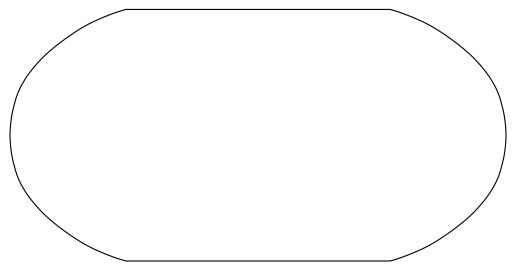

In [4]:
for simu in ['ssp126', 'ssp245', 'ssp370', 'ssp585']:

    dataset_dir = DATASET_DIR / 'MPI-ESM1-2-LR/annual'
    
    inputs = xr.open_dataset(dataset_dir / f'inputs_{simu}_regrid2.nc')
    print(inputs)
    plt.subplot(projection=ccrs.Robinson())
    cs = inputs["CO2"].sel(time=slice('2080', '2100')).mean('time').plot(transform=ccrs.PlateCarree(), add_colorbar=True,
                                                                        cbar_kwargs= {'shrink':0.6})
    plt.gca().coastlines()
    plt.gca().set_title(f'{simu} 2080-2100')
    plt.colorbar(cs, ax=ax, shrink=0.7)
    #plt.savefig(f'/gpfs-calypso/scratch/globc/garcia/scenarIA/graphs/data/Input4MIPs/BC_2080_2100_maps_{simu}.png')
    #plt.close()

[<xarray.DataArray 'longitude' ()> Size: 8B
array(0.), <xarray.DataArray 'longitude' ()> Size: 8B
array(357.5), <xarray.DataArray 'latitude' ()> Size: 8B
array(-90.), <xarray.DataArray 'latitude' ()> Size: 8B
array(90.)]


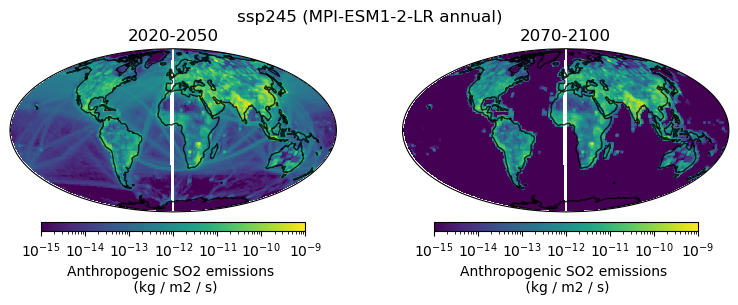

In [8]:
ds = inputs['SO2']
periods = [['2020','2050'], ['2070','2100']]
lonmin, lonmax, latmin, latmax = ds.longitude.min(), ds.longitude.max(), ds.latitude.min(), ds.latitude.max()
extent = [lonmin, lonmax, latmin, latmax]
fig, axes = plt.subplots(1, 2, figsize=(8,3), subplot_kw={'projection': ccrs.Mollweide()})
    #vmin, vmax = y_true.min(), y_true.max()
print(extent)

for i, period in enumerate(periods):
    start = period[0]
    end = period[1]
    #cs = ds.sel(time=slice(start, end)).mean('time').plot(transform=ccrs.PlateCarree(), add_colorbar=False, norm=colors.LogNorm(1e-15, 1e-9, clip=True))
    data = ds.sel(time=slice(start, end)).mean('time').values
    data = np.flip(data, axis=0)
    ax = axes[i]
    cs = ax.imshow(data,
             cmap='viridis',
             extent=extent,
             transform=ccrs.PlateCarree(),
             norm=colors.LogNorm(1e-15, 1e-9, clip=True)
            )

    ax.set_global()
    ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=1, zorder=10, alpha=0.8)
    ax.set_title(f'{start}-{end}')

    cbar = fig.colorbar(cs, ax=ax, shrink=0.7,
                    orientation='horizontal',
                    location='bottom',
                    pad=0.05,
                    aspect=30, 
                    label=f'Anthropogenic SO2 emissions \n (kg / m2 / s)')
    
plt.suptitle(title)
plt.tight_layout()


In [28]:
outputs = xr.open_dataset(dataset_dir / f'outputs_{simu_test}.nc')
clim = xr.open_dataset(dataset_dir / f'outputs_piControl.nc').mean('member')
clim = clim.sel(time=slice('1850', '2250')).mean('time')
outputs = outputs - clim

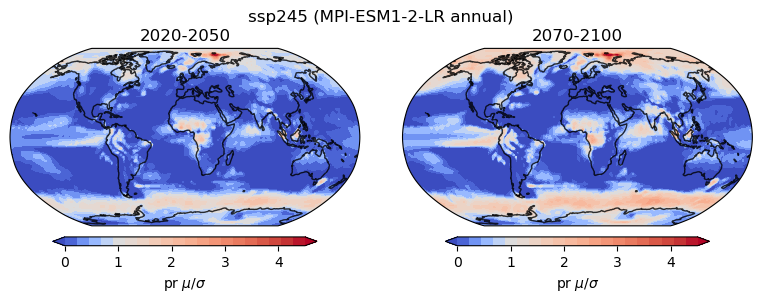

In [112]:
var = 'pr'
ds = outputs[var]
periods = [['2020','2050'], ['2070','2100']]
vmin = 0
vmax = 4.5


fig, axes = plt.subplots(1, 2, figsize=(8,3), subplot_kw={'projection': ccrs.Robinson() })


for i, period in enumerate(periods):
    start = period[0]
    end = period[1]
    data = ds.sel(time=slice(start, end))
    ratio = data.mean('member') / data.std('member')
    ratio = ratio.mean('time')
    ax = axes[i]
    cs = ax.contourf(ratio,
             cmap='coolwarm',
             extent=[0., 360., -90., 90.],
             transform=ccrs.PlateCarree(),
            levels=np.linspace(vmin, vmax, 21),
            extend='both',
            norm = colors.TwoSlopeNorm(vmin=vmin, vcenter=1., vmax=vmax)
            )

    ax.add_feature(cfeature.COASTLINE, edgecolor='black', linewidth=1, zorder=10, alpha=0.8)
    ax.set_title(f'{start}-{end}')

    cbar = fig.colorbar(cs, ax=ax, shrink=0.7,
                    orientation='horizontal',
                    location='bottom',
                    pad=0.05,
                    aspect=30, 
                    label=fr'{var} $\mu/\sigma$')
    
    cbar.set_ticks([0, 1, 2, 3, 4])
    cbar.set_ticklabels([str(i) for i in [0, 1, 2, 3, 4]])
    #cbar.set_ticks(np.linspace(vmin, vmax, 7))
    #cbar.set_ticklabels([str(round(int(i), 1)) for i in np.linspace(vmin, vmax, 7)])
plt.suptitle(title)
plt.tight_layout()